In [1]:
%load_ext autoreload
%autoreload 2
import kwant
import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from koala.lattice import Lattice
from alter_morph.hamiltonians import alt_hamiltonian
from alter_morph.lattice_utilities import alter_lattice_maker,add_contacts
from alter_morph.mean_field import hartree_fock
from alter_morph.kwant_utilities import Amorphous


# plotting
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

First let us construct a regular PBC hamiltonian on our lattice, using all the methods from amorphous_mean_field

In [ ]:
# generate the lattice and set the initial conditions

import koala.graph_utils

# create lattice
system_length = 20
lattice_type = "voronoi"
lattice = alter_lattice_maker(system_length, lattice_type)
lattice = koala.graph_utils.cut_boundaries(lattice, [False, True])

# set parameters
t1 = 1  # orbital parallel neighbor hopping
t2 = 0.5  # orbital perpendicular neighbor hopping
J = 0.4  # Interaction strength
filling = 0.4  # filling of the lattice
n_fock_steps = 10  # number of Fock steps
initial_m = np.full(lattice.n_vertices, 1)  # initial magnetization
initial_parameters = {
    "t1": t1,
    "t2": t2,
    "J": J,
    "filling": filling,
    "initial_m": initial_m,
}
lead_symmetry = np.diag([-1,-1,1,1])


m_values = hartree_fock(lattice, initial_parameters, n_fock_steps)

# make ham and solve
hamiltonian = alt_hamiltonian(
    lattice,
    initial_parameters["t1"],
    initial_parameters["t2"],
    initial_parameters["J"],
    m_values[-1],
)
energies, states = la.eigh(hamiltonian)

Avg:0.73, diff: 0.702331: 100%|██████████| 10/10 [00:12<00:00,  1.24s/it]


Text(0.5, 1.0, 'Magnetisation')

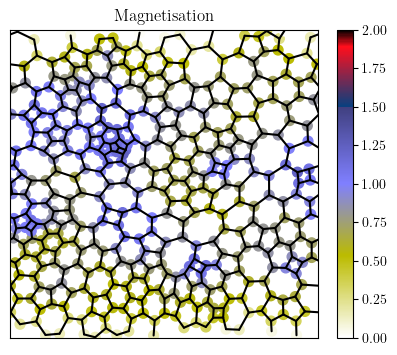

In [15]:
# plot that shit
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
pl.plot_edges(lattice, ax=ax)
im = ax.scatter(
    lattice.vertices.positions[:, 0],
    lattice.vertices.positions[:, 1],
    c=m_values[-1],
    cmap="gist_stern_r",
    s=50,
    vmin=0,
    vmax=2,
)
plt.colorbar(im, ax=ax)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Magnetisation")
# print(lattice)

In [16]:
from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)

n_orbitals = 4
lead_onsite = 1.5*np.eye(n_orbitals)
lead_coupling = np.eye(n_orbitals)

contact_lattice, k_lattice, k_system, contact_vertices = (
    crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
)
kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
    contact_lattice, k_lattice, k_system, contact_vertices, lead_onsite, lead_coupling, lead_symmetry
)

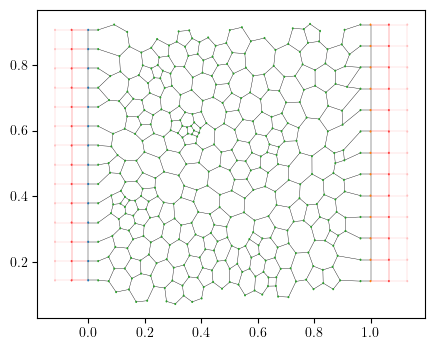

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
kwant.plot(k_system, ax=ax)

In [18]:
k_system_f = k_system.finalized()

smatrix = kwant.smatrix(k_system_f)
g = np.array([[smatrix.transmission((1,j),(0,i)) for j in range(2)] for i in range(2)])
g